#  Detector Mask Pipeline
This notebook creates detector specific masks for:
- module gaps
- chip gaps
- bad pixels

## CHX Olog NoteBook
CHX Olog (https://logbook.nsls2.bnl.gov/11-ID/) [need VPN from offsite location]


In [1]:
from pyCHX.chx_packages import *
%matplotlib notebook
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({ 'image.origin': 'lower'   })
plt.rcParams.update({ 'image.interpolation': 'none'   })
from termcolor import colored
from time import strftime
from pyCHX.chx_xpcs_xsvs_jupyter_V1 import *
from pyCHX.chx_generic_functions import RemoveHot,create_multi_rotated_rectangle_mask
import json

%run /nsls2/data/chx/shared/CHX_Software/packages/environment_management/chx_analysis_setup.ipynb

OBJECT CACHE: Will use up to 121_499_065_958 bytes (15% of total physical RAM)
/nsls2/conda/envs/2024-1.0-py311-tiled-rc1/lib/python3.11/site-packages/databroker/v1.py:72: UserWarning: In databroker 2.x, there are separate notions of 'server' and 'client', and register_handler(...) has no effect on the client. Likely this is being done for you on the server side, so you should not worry about this message unless you encounter trouble loading large array data.
  warnings.warn(


running on: jupyter_hub   environment: standard

setting '_base_path_' as /nsls2/data/chx/legacy/analysis/
setting '_mask_path_' as /nsls2/data/chx/shared/CHX_Setup/Detector_masks/

ran "%run -i /nsls2/data/chx/shared/CHX_Software/packages/patches/roi_nr_2019_3_0_1.py" to fix ROI numbering for PHI-sliced data sets. Should get fixed in pyCHX...
ran "%run -i /nsls2/data/chx/shared/CHX_Software/packages/patches/chx_outlier_detection.py": this should become part of pyCHX.
ran "%run -i /nsls2/data/chx/shared/CHX_Software/packages/patches/fix_get_sid_filenames.py": this should be fixed and re-deployed in pyCHX.

environment dependent settings and patches:
using "%matplotlib inline" for plotting
ran "%run -i /nsls2/data/chx/shared/CHX_Software/packages/patches/polygonmask_fix.py".
ran "%run -i /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/chx_compress.py": temporary fix for depreciated np.float.
ran "%run -i /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/chx_correlationc.py": tempora

### DARK image series to find bad pixels on the detector (typically 5 images, 1s)

In [4]:
#uid = '66cca048' # (scan num: 134037) (Measurement: dark images 4M for mask )
uid = '17646add' # (scan num: 134038) (Measurement: dark images 500k for mask )

In [5]:
md = get_meta_data( uid )
detector = get_detector( db[uid ] )
print ('Detector is:  %s'%detector  )
sud = get_sid_filenames(db[uid])

print ('scan_id, full-uid, data path are:  %s--%s--%s'%(sud[0], sud[1], sud[2][0] ))

## image rotations from analysis pipeline:
if md['detector'] =='eiger4m_single_image' or md['detector'] == 'image':    
    reverse= True
    rot90= False
elif md['detector'] =='eiger500K_single_image':    
    reverse= True
    rot90=True
elif md['detector'] =='eiger1m_single_image':    
    reverse= True
    rot90=False
print('detector: %s -> Image reverse: %s, Image rotate 90: %s'%(md['detector'].split('_')[0],reverse, rot90))

Detector is:  eiger500K_single_image
scan_id, full-uid, data path are:  134038--17646add-3c7e-4212-8d58-08d6ec50d227--/nsls2/data/chx/legacy/data/2023/05/31/d04b833a-8fbe-455d-97e8_434_data_000001.h5
detector: eiger500K -> Image reverse: True, Image rotate 90: True


In [6]:
imgs = load_data( uid, detector, reverse= reverse,rot90=rot90  )
#imgs = load_data( uid, detector, reverse= True  )
md.update( imgs.md );Nimg = len(imgs);
#if 'number of images'  not in list(md.keys()):
md['number of images']  = Nimg

pixel_mask = 1- np.int_( np.array( imgs.md['pixel_mask'], dtype= bool)  )
print( 'The data are: %s' %imgs )

if detector =='eiger1m_single_image':
    chip_mask_name ='%sEiger1M_Chip_Mask.npy'%(_mask_path_+'chip_masks/')
    chip_mask=np.load( chip_mask_name )
    bad_pixel_list_name = 'None'
elif detector =='eiger4m_single_image' or md['detector'] == 'image':
    chip_mask_name = '%sEiger4M_Chip_Mask.npy'%(_mask_path_+'chip_masks/')
    chip_mask= np.array(np.load(chip_mask_name), dtype=bool)
    bad_pixel_list_name='%s2019_2/BadPix_4M.npy'%_base_path_
    BadPix =     np.load(bad_pixel_list_name )  
    pixel_mask.ravel()[BadPix] = 0
    pixel_mask = reverse_updown( pixel_mask )
elif detector =='eiger500K_single_image':
    chip_mask_name = '%sEiger500K_Chip_Mask.npy'%(_mask_path_+'chip_masks/')
    chip_mask=  np.load( chip_mask_name )
    chip_mask = np.rot90(chip_mask)
    pixel_mask = np.rot90(  pixel_mask  )
    bad_pixel_list_name = 'None'

The data are: (Pipeline,) processed through proc_func. Original repr:
    (Pipeline,) processed through proc_func. Original repr:
        (Images,) processed through proc_func. Original repr:
            <Frames>
            Length: 5 frames
            Frame Shape: 514 x 1030
            Pixel Datatype: uint32


### Check for bad pixels in dark images -> pixels that have counts >1 in at least 2 frames are considered 'bad' (this should avoid catching cosmic rays as 'bad' pixels)

In [7]:
s=np.shape(imgs);fr=s[0];dims=(s[1],s[2])
darks_mask = np.zeros(s)
darks_mask_ = np.zeros(s)
for f in range(fr):
    darks_mask_[f][(imgs[f]*pixel_mask*chip_mask)>0]=1
    darks_mask[f][(imgs[f]*chip_mask)>0]=1
dark_mask = np.ones(dims)
dark_mask_ = np.ones(dims)
dark_mask[np.sum(darks_mask,axis=0)>2]=0
dark_mask_[np.sum(darks_mask_,axis=0)>2]=0

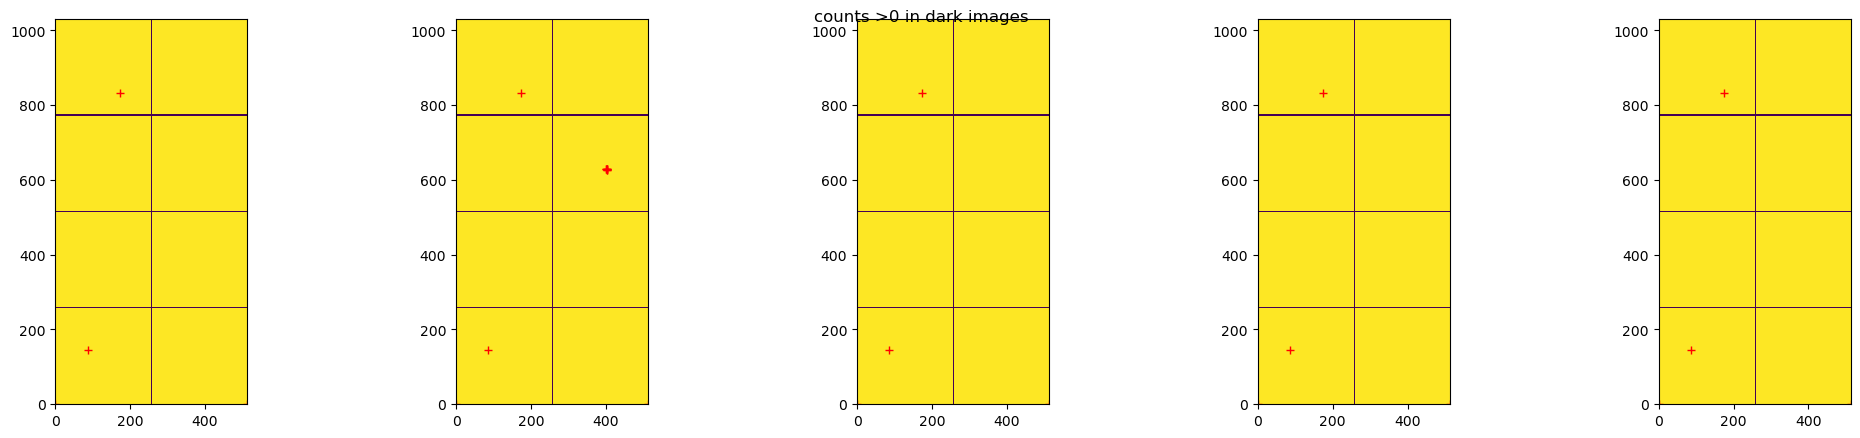

In [8]:
fig,ax = plt.subplots(1,5,figsize = (25,5))
plt.suptitle('counts >0 in dark images',y=.9)
for i in range(np.max([5,darks_mask.shape[0]])):
    plt.subplot(1,5,i+1)
    plt.imshow(chip_mask)
    masked=np.nonzero(darks_mask[i]>0)
    plt.plot(masked[1],masked[0],'r+')

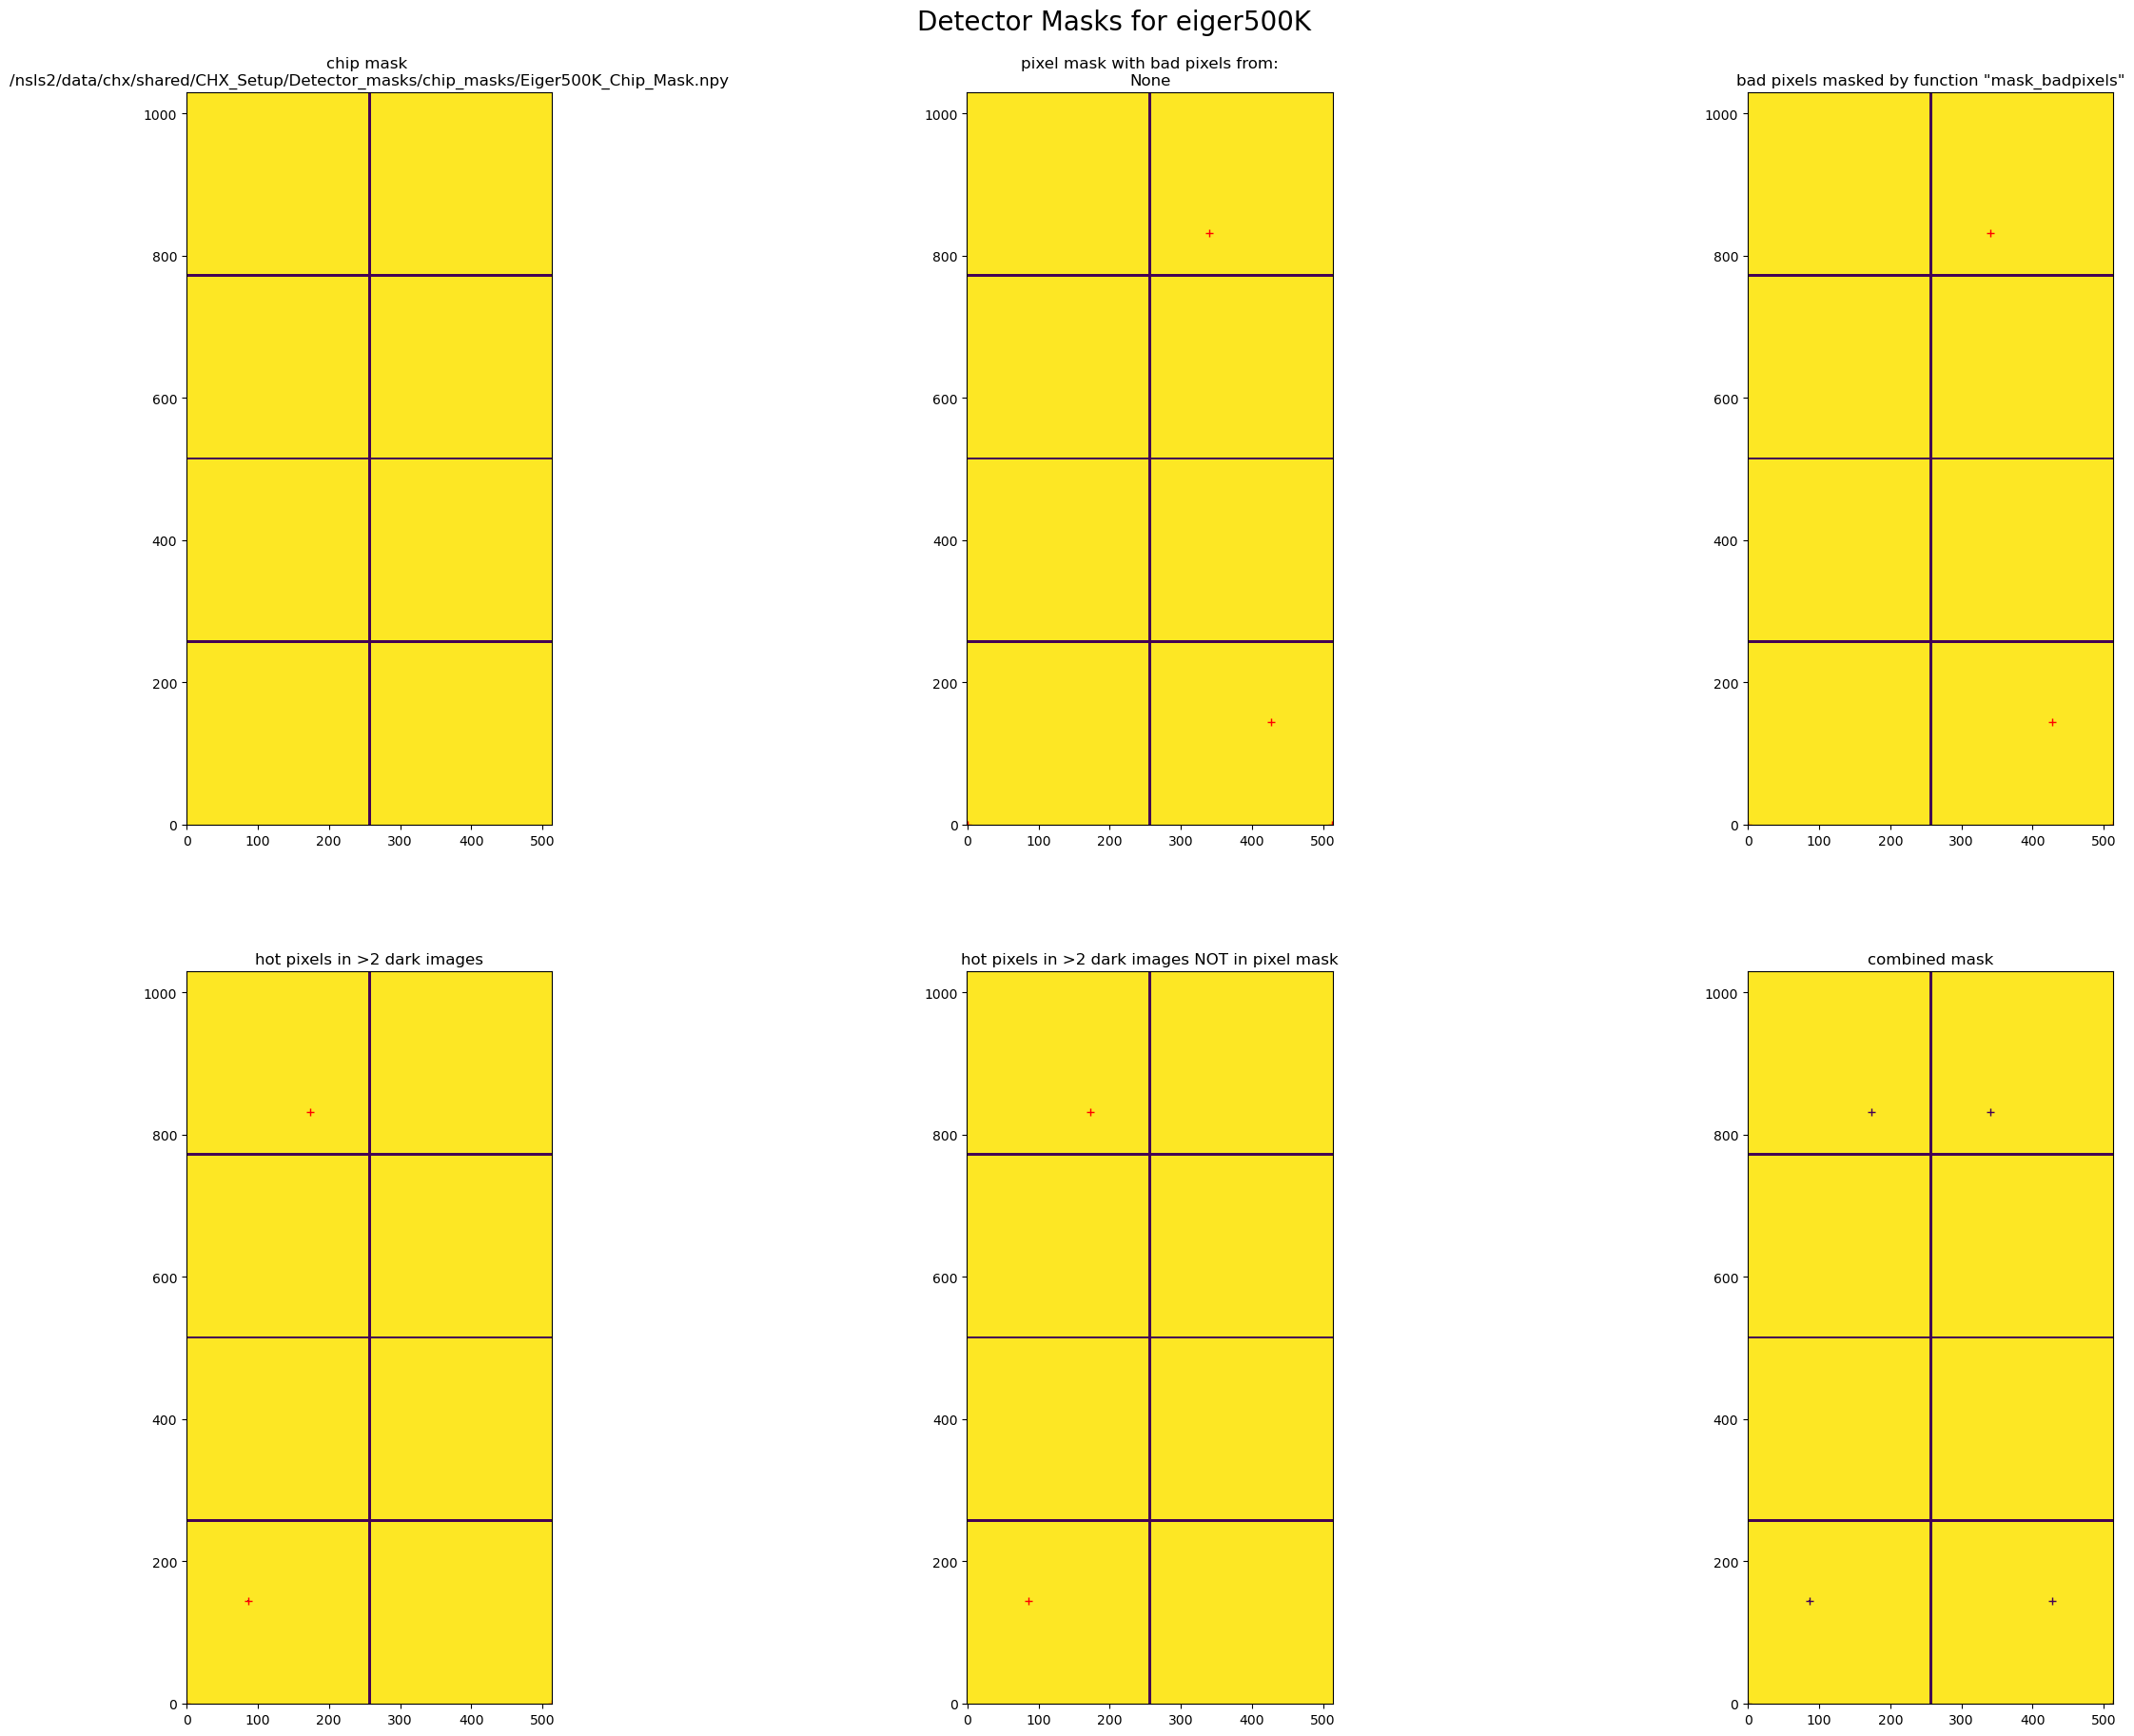

In [9]:
fig,ax = plt.subplots(2,3,figsize = (30,22))
plt.suptitle('Detector Masks for %s'%detector.split('_')[0], fontsize=20,y=.92)

plt.subplot(2,3,1);plt.title('chip mask \n%s'%chip_mask_name)
plt.imshow(chip_mask)

plt.subplot(2,3,2);plt.title('pixel mask with bad pixels from:\n%s'%bad_pixel_list_name)
plt.imshow(chip_mask)
masked=np.nonzero(pixel_mask+~chip_mask<1)
plt.plot(masked[1],masked[0],'r+')

plt.subplot(2,3,3);plt.title('bad pixels masked by function "mask_badpixels"')
bad_pix_mask = np.ones(pixel_mask.shape)
bad_pix_mask = mask_badpixels( pixel_mask, md['detector'])
plt.imshow(bad_pix_mask*chip_mask)
masked=np.nonzero(bad_pix_mask+~chip_mask<1)
plt.plot(masked[1],masked[0],'r+')

plt.subplot(2,3,4);plt.title('hot pixels in >2 dark images')
plt.imshow(dark_mask*chip_mask)
hot_dark=np.nonzero(dark_mask+~chip_mask<1)
plt.plot(hot_dark[1],hot_dark[0],'r+')

plt.subplot(2,3,5);plt.title('hot pixels in >2 dark images NOT in pixel mask')
plt.imshow(chip_mask)
hot_dark=np.nonzero(dark_mask_+~chip_mask<1)
plt.plot(hot_dark[1],hot_dark[0],'r+')

plt.subplot(2,3,6);plt.title('combined mask')
plt.imshow(chip_mask*pixel_mask*bad_pix_mask*dark_mask)
hot_dark=np.nonzero(pixel_mask*bad_pix_mask*dark_mask_+~chip_mask<1)
cmap=plt.colormaps['viridis']
plt.plot(hot_dark[1],hot_dark[0],'+',color=cmap(0))

In [10]:
if True:
    det_mask_dict = {'uid':md['uid'],'detector':md['detector'].split('_')[0],'masks':{'dark_mask':np.array(dark_mask,dtype=bool).tolist(),'pixel_mask':np.array(pixel_mask*bad_pix_mask,dtype=bool).tolist(),'chip_mask':np.array(chip_mask,dtype=bool).tolist()}}
    mask_filename = 'detector_mask_%s.json'%det_mask_dict['detector']
    path = _mask_path_+'pixel_masks/'
    if os.path.isfile(path+mask_filename): # file exists, check if overwriting is ok
        print(colored('file %s exists and should not be overwritten.'%(path+mask_filename),'red'))
        print('Rename existing file, e.g. as %s, and try saving again.'%(mask_filename.split('.')[0]+'_%s.json'%strftime('%m%d%Y',time.localtime())))
        print(colored('DATA NOT WRITTEN TO FILE!','red'))
    else: 
        with open(path+mask_filename, "w") as outfile:
            json.dump(det_mask_dict, outfile)
        print(colored('metadata has been written to %s'%path+mask_filename,'green'))
        
        
        

file /nsls2/data/chx/shared/CHX_Setup/Detector_masks/pixel_masks/detector_mask_eiger500K.json exists and should not be overwritten.
Rename existing file, e.g. as detector_mask_eiger500K, and try saving again._04172024.json
DATA NOT WRITTEN TO FILE!
